<a href="https://colab.research.google.com/github/aribarahmanii/Breasttumor/blob/main/sem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os, zipfile

In [2]:
import kagglehub
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Dataset downloaded to: /kaggle/input/breast-ultrasound-images-dataset


In [3]:
print(os.listdir(path))

['Dataset_BUSI_with_GT']


In [4]:
IMG_SIZE = 256
DATA_DIR = path

imgs_raw_list, masks_list, labels_list = [], [], []

classes = {'benign': 0, 'malignant': 1}

for cls_name, cls_label in classes.items():
    cls_dir = os.path.join(DATA_DIR, "Dataset_BUSI_with_GT", cls_name)
    files = sorted(os.listdir(cls_dir))
    image_files = [f for f in files if f.endswith('.png') and 'mask' not in f]

    for img_file in image_files:
        img_path = os.path.join(cls_dir, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        base_name = img_file.replace('.png', '')
        mask_files = [f for f in files if f.startswith(base_name + '_mask')]

        combined_mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype='float32')
        for mf in mask_files:
            m = cv2.imread(os.path.join(cls_dir, mf), cv2.IMREAD_GRAYSCALE)
            m = cv2.resize(m, (IMG_SIZE, IMG_SIZE))
            combined_mask = np.maximum(combined_mask, (m > 127).astype('float32'))

        imgs_raw_list.append(img)
        masks_list.append(combined_mask[..., np.newaxis])
        labels_list.append(cls_label)

imgs_raw = np.array(imgs_raw_list)
masks = np.array(masks_list)
labels = np.array(labels_list)
imgs_norm = (imgs_raw / 255.0)[..., np.newaxis]

print("imgs_raw:", imgs_raw.shape, "masks:", masks.shape, "labels:", labels.shape)

imgs_raw: (647, 256, 256) masks: (647, 256, 256, 1) labels: (647,)


In [5]:
from sklearn.model_selection import train_test_split

n = len(imgs_raw)
all_idx = np.arange(n)

idx_train, idx_temp = train_test_split(all_idx, test_size=0.3, stratify=labels, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, stratify=labels[idx_temp], random_state=42)

print("train:", len(idx_train), "val:", len(idx_val), "test:", len(idx_test))

train: 452 val: 97 test: 98


In [6]:
def dice_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    inter = np.sum(gt * pred)
    return (2. * inter + smooth) / (np.sum(gt) + np.sum(pred) + smooth)

def clean_mask(mask):
    mask_u8 = (mask > 0).astype('uint8')
    n_labels, labels_im, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    if n_labels <= 1:
        return mask_u8.astype('float32')
    h, w = mask_u8.shape
    best_label, best_area = 0, 0
    for lbl in range(1, n_labels):
        x, y, bw, bh, area = stats[lbl]
        touches_border = (x == 0 or y == 0 or x + bw == w or y + bh == h)
        if not touches_border and area > best_area:
            best_area, best_label = area, lbl
    return (labels_im == best_label).astype('float32')

In [7]:
!git clone https://github.com/bowang-lab/MedSAM.git
%cd MedSAM
!pip install -e .
%cd ..

Cloning into 'MedSAM'...
remote: Enumerating objects: 967, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 967 (delta 102), reused 95 (delta 95), pack-reused 842 (from 1)
Receiving objects: 100% (967/967), 62.52 MiB | 32.81 MiB/s, done.
Resolving deltas: 100% (477/477), done.
/content/MedSAM
Obtaining file:///content/MedSAM
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 128.5 MB/s eta 0:00:00
  Running

In [8]:
!pip install gdown
import gdown
gdown.download(id="1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_", output="medsam_vit_b.pth", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_
From (redirected): https://drive.google.com/uc?id=1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_&confirm=t&uuid=1e6b1fd0-c03a-410a-9c5f-24426ff5dc80
To: /content/medsam_vit_b.pth
100%|██████████| 375M/375M [00:03<00:00, 97.6MB/s]


'medsam_vit_b.pth'

In [9]:
import sys
sys.path.append('MedSAM')
from segment_anything import sam_model_registry
import torch
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
medsam_model = sam_model_registry['vit_b'](checkpoint='medsam_vit_b.pth').to(device)
medsam_model.eval()

def get_bbox_from_mask(mask, pad=5):
    ys, xs = np.where(mask > 0.5)
    if len(xs) == 0:
        return None
    x0, x1 = max(0, xs.min() - pad), min(mask.shape[1], xs.max() + pad)
    y0, y1 = max(0, ys.min() - pad), min(mask.shape[0], ys.max() + pad)
    return np.array([x0, y0, x1, y1])

@torch.no_grad()
def medsam_inference(img_uint8, box, size=1024):
    img_rgb = np.stack([img_uint8]*3, axis=-1)
    img_resized = cv2.resize(img_rgb, (size, size))
    img_tensor = torch.tensor(img_resized).permute(2, 0, 1).unsqueeze(0).float().to(device) / 255.0

    image_embedding = medsam_model.image_encoder(img_tensor)
    box_scaled = box / np.array([img_uint8.shape[1], img_uint8.shape[0],
                                  img_uint8.shape[1], img_uint8.shape[0]]) * size
    box_t = torch.as_tensor(box_scaled, dtype=torch.float32, device=device).unsqueeze(0)

    sparse_emb, dense_emb = medsam_model.prompt_encoder(points=None, boxes=box_t, masks=None)
    low_res_logits, _ = medsam_model.mask_decoder(
        image_embeddings=image_embedding,
        image_pe=medsam_model.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse_emb,
        dense_prompt_embeddings=dense_emb,
        multimask_output=False,
    )
    pred = torch.sigmoid(low_res_logits)
    pred = F.interpolate(pred, size=(img_uint8.shape[0], img_uint8.shape[1]), mode='bilinear', align_corners=False)
    return (pred.squeeze().cpu().numpy() > 0.5).astype('float32')

medsam_dices = []
for i in idx_test[:5]:
    img_u8 = imgs_raw[i]
    gt = masks[i, ..., 0]
    box = get_bbox_from_mask(gt)
    if box is None:
        continue
    pred_mask = medsam_inference(img_u8, box)
    medsam_dices.append(dice_score(gt, pred_mask))

print('MedSAM mean Dice (5 samples):', np.mean(medsam_dices))

MedSAM mean Dice (5 samples): 0.9420969


In [10]:
medsam_dices_full = []
for i in idx_test:
    img_u8 = imgs_raw[i]
    gt = masks[i, ..., 0]
    box = get_bbox_from_mask(gt)
    if box is None:
        continue
    pred_mask = medsam_inference(img_u8, box)
    medsam_dices_full.append(dice_score(gt, pred_mask))

print(f'MedSAM mean Dice (full test set, n={len(medsam_dices_full)}):', np.mean(medsam_dices_full))

MedSAM mean Dice (full test set, n=98): 0.9361132


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x

def build_unet(input_size=(IMG_SIZE, IMG_SIZE, 1)):
    inputs = layers.Input(input_size)
    c1 = conv_block(inputs, 32); p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 64);     p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 128);    p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 256);    p4 = layers.MaxPooling2D()(c4)
    bn = conv_block(p4, 512)
    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(bn)
    u4 = layers.Concatenate()([u4, c4]); d4 = conv_block(u4, 256)
    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(d4)
    u3 = layers.Concatenate()([u3, c3]); d3 = conv_block(u3, 128)
    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(d3)
    u2 = layers.Concatenate()([u2, c2]); d2 = conv_block(u2, 64)
    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(d2)
    u1 = layers.Concatenate()([u1, c1]); d1 = conv_block(u1, 32)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d1)
    return models.Model(inputs, outputs, name='U-Net')

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true); y_pred_f = K.flatten(y_pred)
    inter = K.sum(y_true_f * y_pred_f)
    return (2. * inter + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def bce_dice_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + (1 - dice_coef(y_true, y_pred))

unet = build_unet()
unet.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=bce_dice_loss, metrics=[dice_coef])
unet.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[

 Total params: 7,771,297 (29.65 MB)

 Trainable params: 7,765,409 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [12]:
X_train, y_train = imgs_norm[idx_train], masks[idx_train]
X_val, y_val = imgs_norm[idx_val], masks[idx_val]
X_test, y_test = imgs_norm[idx_test], masks[idx_test]
print(X_train.shape, X_val.shape, X_test.shape)

(452, 256, 256, 1) (97, 256, 256, 1) (98, 256, 256, 1)


In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', mode='max', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6),
]

history = unet.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=16, callbacks=callbacks)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - dice_coef: 0.1880 - loss: 1.5370 - val_dice_coef: 0.1546 - val_loss: 1.4784 - learning_rate: 1.0000e-04
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 302ms/step - dice_coef: 0.2493 - loss: 1.3523 - val_dice_coef: 0.1497 - val_loss: 1.3886 - learning_rate: 1.0000e-04
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 304ms/step - dice_coef: 0.2712 - loss: 1.2706 - val_dice_coef: 0.1424 - val_loss: 1.3100 - learning_rate: 1.0000e-04
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 306ms/step - dice_coef: 0.2987 - loss: 1.1949 - val_dice_coef: 0.1355 - val_loss: 1.2640 - learning_rate: 1.0000e-04
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 307ms/step - dice_coef: 0.3201 - loss: 1.1424 - val_dice_coef: 0.1299 - val_loss: 1.2443 - learning_rate: 1.0000e-04
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 308ms/step - dice_coef: 0.3371 - loss: 1.0746 - val_dice_coef: 0.1216 - val_loss: 1.2248 - learning_rate: 1.0000e-04
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 310ms

In [14]:
unet_preds = unet.predict(X_test)
unet_dices = [dice_score(y_test[k, ..., 0], unet_preds[k, ..., 0]) for k in range(len(X_test))]
print('U-Net mean Dice (full test set):', np.mean(unet_dices))

4/4 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step
U-Net mean Dice (full test set): 0.60185575


In [15]:
unet_preds = unet.predict(X_test)
unet_dices = [dice_score(y_test[k, ..., 0], unet_preds[k, ..., 0]) for k in range(len(X_test))]
print('U-Net mean Dice (full test set):', np.mean(unet_dices))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step
U-Net mean Dice (full test set): 0.60185575


In [16]:
def pixel_accuracy(gt, pred):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    return np.sum(gt == pred) / len(gt)

def precision_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    tp = np.sum(gt * pred)
    fp = np.sum((1 - gt) * pred)
    return (tp + smooth) / (tp + fp + smooth)

def sensitivity_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    tp = np.sum(gt * pred)
    fn = np.sum(gt * (1 - pred))
    return (tp + smooth) / (tp + fn + smooth)

def specificity_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    tn = np.sum((1 - gt) * (1 - pred))
    fp = np.sum((1 - gt) * pred)
    return (tn + smooth) / (tn + fp + smooth)

def iou_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    inter = np.sum(gt * pred)
    union = np.sum(gt) + np.sum(pred) - inter
    return (inter + smooth) / (union + smooth)

def evaluate_all(gt, pred):
    return {
        'dice': dice_score(gt, pred),
        'iou': iou_score(gt, pred),
        'accuracy': pixel_accuracy(gt, pred),
        'precision': precision_score(gt, pred),
        'sensitivity': sensitivity_score(gt, pred),
        'specificity': specificity_score(gt, pred),
    }

metric_names = ['dice', 'iou', 'accuracy', 'precision', 'sensitivity', 'specificity']

unet_preds = unet.predict(X_test)
unet_results = {m: [] for m in metric_names}
for k in range(len(X_test)):
    scores = evaluate_all(y_test[k, ..., 0], unet_preds[k, ..., 0])
    for m in metric_names:
        unet_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(unet_results[m]):>15.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step
Metric              Mean Score
------------------------------
Dice                    0.6019
Iou                     0.5295
Accuracy                0.9315
Precision               0.7290
Sensitivity             0.5806
Specificity             0.9899


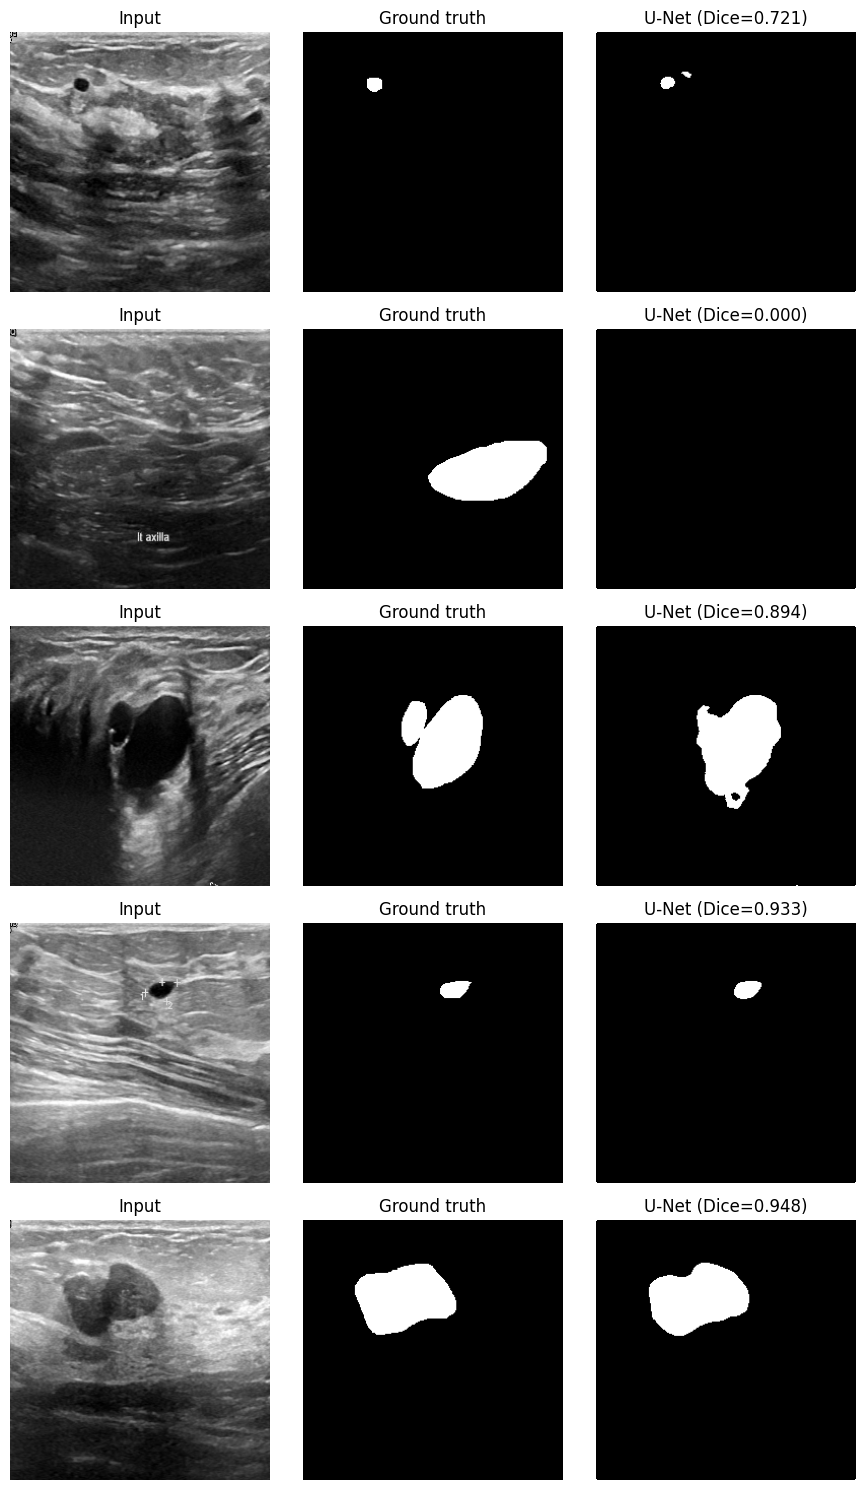

In [17]:
fig, axes = plt.subplots(5, 3, figsize=(9, 15))
for row, idx_num in enumerate(range(5)):
    k = idx_num
    axes[row, 0].imshow(X_test[k, ..., 0], cmap='gray')
    axes[row, 0].set_title('Input')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(y_test[k, ..., 0], cmap='gray')
    axes[row, 1].set_title('Ground truth')
    axes[row, 1].axis('off')

    pred_binary = unet_preds[k, ..., 0] > 0.5
    d = dice_score(y_test[k, ..., 0], pred_binary)
    axes[row, 2].imshow(pred_binary, cmap='gray')
    axes[row, 2].set_title(f'U-Net (Dice={d:.3f})')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

In [18]:
def build_classifier(input_size=(IMG_SIZE, IMG_SIZE, 1)):
    inputs = layers.Input(input_size)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu', name='last_conv')(x)
    gap = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(1, activation='sigmoid')(gap)
    return models.Model(inputs, out, name='classifier')

clf = build_classifier()
clf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
clf.fit(imgs_norm[idx_train], labels[idx_train].astype('float32'),
        validation_data=(imgs_norm[idx_val], labels[idx_val].astype('float32')),
        epochs=30, batch_size=16)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - accuracy: 0.6704 - loss: 0.6391 - val_accuracy: 0.6804 - val_loss: 0.6219
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6748 - loss: 0.6296 - val_accuracy: 0.6804 - val_loss: 0.6219
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6748 - loss: 0.6289 - val_accuracy: 0.6804 - val_loss: 0.6252
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6748 - loss: 0.6255 - val_accuracy: 0.6804 - val_loss: 0.6109
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6748 - loss: 0.6249 - val_accuracy: 0.6804 - val_loss: 0.6075
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6748 - loss: 0.6111 - val_accuracy: 0.6804 - val_loss: 0.6275
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6814 - loss: 0.5998 - val_accuracy: 0.6701 - val_loss: 0.5803
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7212 - loss: 0.5731 - val_accuracy: 0.6701 - 

In [19]:
def grad_cam(model, img_array, layer_name='last_conv'):
    grad_model = models.Model([model.inputs], [model.get_layer(layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array[np.newaxis, ...])
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def gradcam_to_mask(heatmap, size=IMG_SIZE, thresh=0.5):
    return (cv2.resize(heatmap, (size, size)) > thresh).astype('float32')

In [20]:
gradcam_results = {m: [] for m in metric_names}
gradcam_preds_binary = []

for i in idx_test:
    heatmap = grad_cam(clf, imgs_norm[i])
    pred_mask = clean_mask(gradcam_to_mask(heatmap))
    gradcam_preds_binary.append(pred_mask)
    scores = evaluate_all(masks[i, ..., 0], pred_mask)
    for m in metric_names:
        gradcam_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(gradcam_results[m]):>15.4f}")

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_50']]
Received: inputs=Tensor(shape=(1, 256, 256, 1))
  warnings.warn(msg)


Metric              Mean Score
------------------------------
Dice                    0.1265
Iou                     0.0735
Accuracy                0.3585
Precision               0.1973
Sensitivity             0.6742
Specificity             0.3424


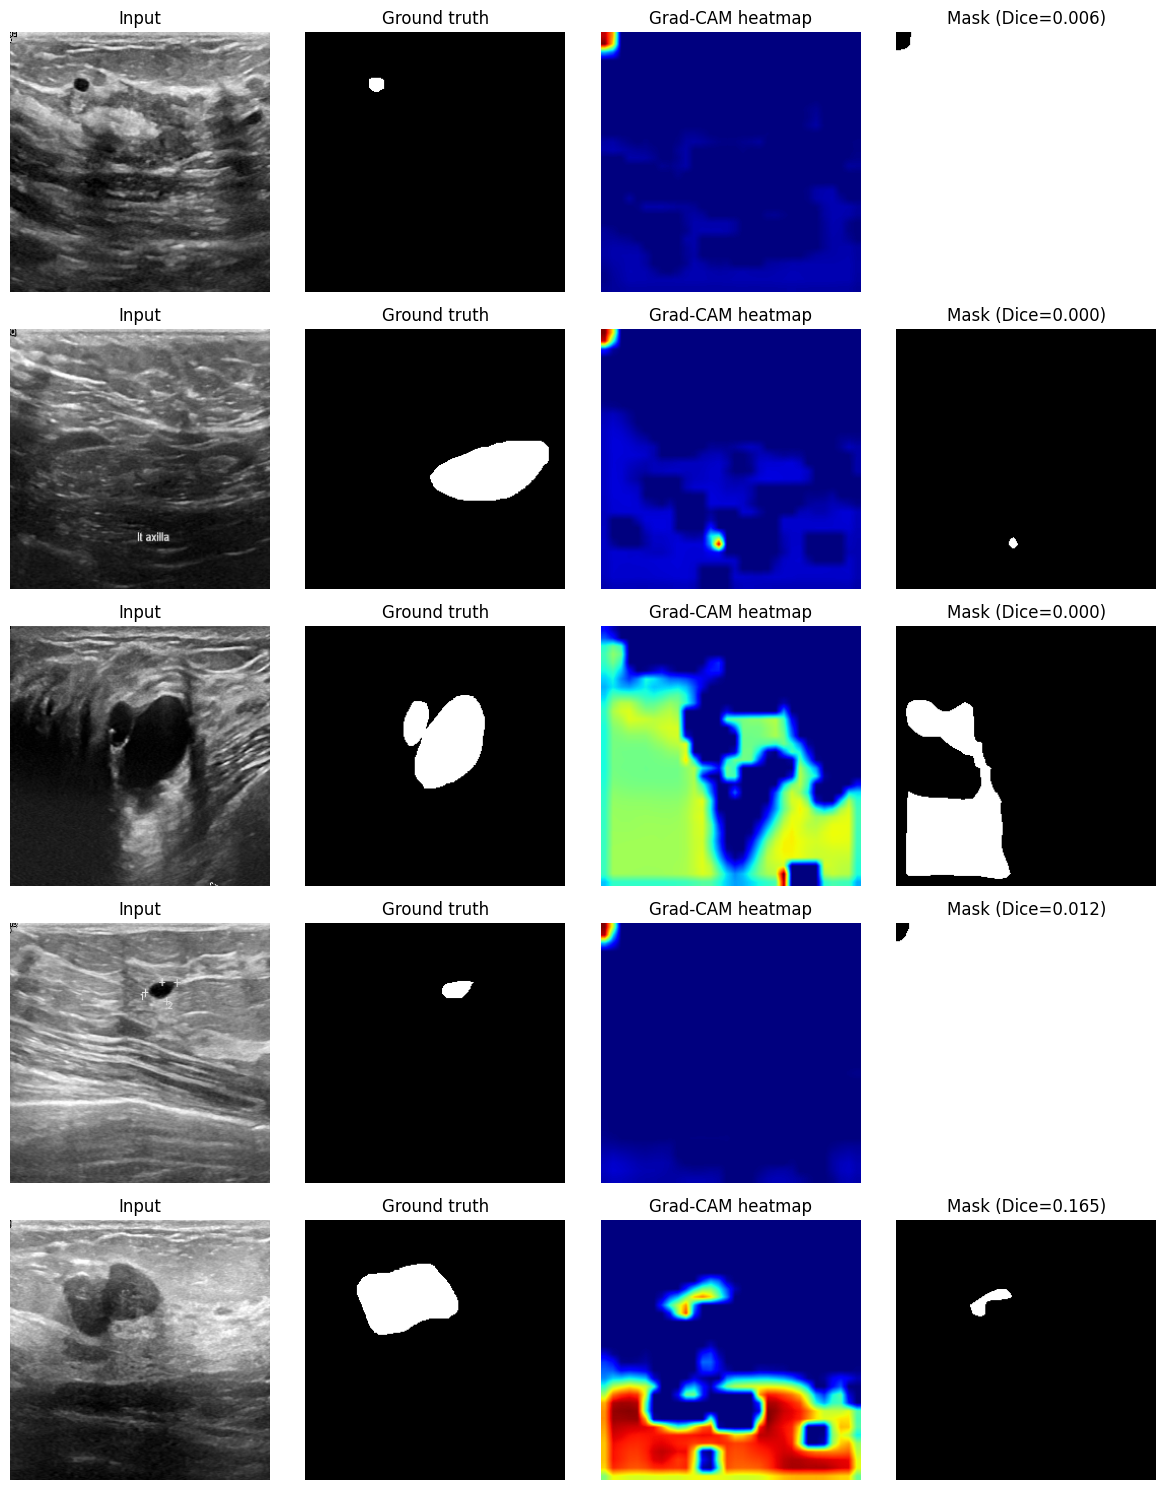

In [21]:
fig, axes = plt.subplots(5, 4, figsize=(12, 15))
for row, i in enumerate(idx_test[:5]):
    img = imgs_norm[i]
    gt = masks[i, ..., 0]
    heatmap = grad_cam(clf, img)
    pred_mask = clean_mask(gradcam_to_mask(heatmap))
    d = dice_score(gt, pred_mask)

    axes[row, 0].imshow(img[..., 0], cmap='gray'); axes[row, 0].set_title('Input'); axes[row, 0].axis('off')
    axes[row, 1].imshow(gt, cmap='gray'); axes[row, 1].set_title('Ground truth'); axes[row, 1].axis('off')
    axes[row, 2].imshow(cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE)), cmap='jet'); axes[row, 2].set_title('Grad-CAM heatmap'); axes[row, 2].axis('off')
    axes[row, 3].imshow(pred_mask, cmap='gray'); axes[row, 3].set_title(f'Mask (Dice={d:.3f})'); axes[row, 3].axis('off')

plt.tight_layout()
plt.show()

In [22]:
print(f"{'Metric':<15}{'U-Net':>15}{'Grad-CAM':>15}")
print('-' * 45)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(unet_results[m]):>15.4f}{np.mean(gradcam_results[m]):>15.4f}")

Metric                   U-Net       Grad-CAM
---------------------------------------------
Dice                    0.6019         0.1265
Iou                     0.5295         0.0735
Accuracy                0.9315         0.3585
Precision               0.7290         0.1973
Sensitivity             0.5806         0.6742
Specificity             0.9899         0.3424


In [23]:
medsam_results = {m: [] for m in metric_names}

for i in idx_test:
    img_u8 = imgs_raw[i]
    gt = masks[i, ..., 0]
    box = get_bbox_from_mask(gt)
    if box is None:
        continue
    pred_mask = medsam_inference(img_u8, box)
    scores = evaluate_all(gt, pred_mask)
    for m in metric_names:
        medsam_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(medsam_results[m]):>15.4f}")

Metric              Mean Score
------------------------------
Dice                    0.9361
Iou                     0.8820
Accuracy                0.9852
Precision               0.9256
Sensitivity             0.9495
Specificity             0.9888


In [24]:
print(f"{'Metric':<15}{'U-Net':>15}{'Grad-CAM':>15}{'MedSAM':>15}")
print('-' * 60)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(unet_results[m]):>15.4f}{np.mean(gradcam_results[m]):>15.4f}{np.mean(medsam_results[m]):>15.4f}")

Metric                   U-Net       Grad-CAM         MedSAM
------------------------------------------------------------
Dice                    0.6019         0.1265         0.9361
Iou                     0.5295         0.0735         0.8820
Accuracy                0.9315         0.3585         0.9852
Precision               0.7290         0.1973         0.9256
Sensitivity             0.5806         0.6742         0.9495
Specificity             0.9899         0.3424         0.9888


In [25]:
import torch, torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from scipy import ndimage

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

class BUSIInstanceDataset(Dataset):
    def __init__(self, indices): self.indices = indices
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        i = self.indices[idx]
        img = imgs_raw[i]; mask = masks[i, ..., 0]
        labeled, n = ndimage.label(mask > 0.5)
        boxes, inst_masks, cls_labels = [], [], []
        for inst_id in range(1, n + 1):
            inst_mask = (labeled == inst_id)
            ys, xs = np.where(inst_mask)
            if len(xs) == 0: continue
            boxes.append([xs.min(), ys.min(), xs.max(), ys.max()])
            inst_masks.append(inst_mask); cls_labels.append(1)
        if len(boxes) == 0:
            boxes = [[0, 0, 1, 1]]; inst_masks = [np.zeros_like(mask, dtype=bool)]; cls_labels = [1]
        img_rgb = np.stack([img]*3, axis=0).astype('float32') / 255.0
        target = {'boxes': torch.as_tensor(boxes, dtype=torch.float32),
                  'labels': torch.as_tensor(cls_labels, dtype=torch.int64),
                  'masks': torch.as_tensor(np.stack(inst_masks), dtype=torch.uint8),
                  'image_id': torch.tensor([i])}
        return torch.tensor(img_rgb), target

def collate_fn(batch): return tuple(zip(*batch))
train_loader = DataLoader(BUSIInstanceDataset(idx_train), batch_size=4, shuffle=True, collate_fn=collate_fn)

Using device: cuda


In [26]:
mrcnn = maskrcnn_resnet50_fpn(weights='DEFAULT')
in_feat = mrcnn.roi_heads.box_predictor.cls_score.in_features
mrcnn.roi_heads.box_predictor = FastRCNNPredictor(in_feat, 2)
in_feat_mask = mrcnn.roi_heads.mask_predictor.conv5_mask.in_channels
mrcnn.roi_heads.mask_predictor = MaskRCNNPredictor(in_feat_mask, 256, 2)
mrcnn = mrcnn.to(device)

optimizer = torch.optim.SGD(mrcnn.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
print("Model ready")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 171MB/s]


Model ready


In [27]:
class BUSIInstanceDataset(Dataset):
    def __init__(self, indices): self.indices = indices
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        i = self.indices[idx]
        img = imgs_raw[i]; mask = masks[i, ..., 0]
        labeled, n = ndimage.label(mask > 0.5)
        boxes, inst_masks, cls_labels = [], [], []
        for inst_id in range(1, n + 1):
            inst_mask = (labeled == inst_id)
            ys, xs = np.where(inst_mask)
            if len(xs) < 10:  # skip tiny/noise blobs outright (fewer than 10 pixels)
                continue
            x0, x1 = int(xs.min()), int(xs.max()) + 1   # +1 guarantees positive width
            y0, y1 = int(ys.min()), int(ys.max()) + 1   # +1 guarantees positive height
            x1 = min(x1, mask.shape[1])                  # clip to image bounds
            y1 = min(y1, mask.shape[0])
            if x1 - x0 < 4 or y1 - y0 < 4:                # extra safety margin before resize
                continue
            boxes.append([x0, y0, x1, y1])
            inst_masks.append(inst_mask)
            cls_labels.append(1)

        if len(boxes) == 0:
            boxes = [[10, 10, 20, 20]]  # safely-sized dummy box, well clear of zero-area
            inst_masks = [np.zeros_like(mask, dtype=bool)]
            cls_labels = [1]

        img_rgb = np.stack([img]*3, axis=0).astype('float32') / 255.0
        target = {'boxes': torch.as_tensor(boxes, dtype=torch.float32),
                  'labels': torch.as_tensor(cls_labels, dtype=torch.int64),
                  'masks': torch.as_tensor(np.stack(inst_masks), dtype=torch.uint8),
                  'image_id': torch.tensor([i])}
        return torch.tensor(img_rgb), target

train_loader = DataLoader(BUSIInstanceDataset(idx_train), batch_size=4, shuffle=True, collate_fn=collate_fn)
print("Dataset ready, size:", len(train_loader.dataset))

Dataset ready, size: 452


In [28]:
for epoch in range(10):
    mrcnn.train()
    epoch_loss = 0
    for imgs_b, targets in train_loader:
        imgs_b = [im.to(device) for im in imgs_b]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = mrcnn(imgs_b, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    lr_scheduler.step()
    print(f'Epoch {epoch+1}/10 — loss: {epoch_loss/len(train_loader):.4f}')

Epoch 1/10 — loss: 0.5768
Epoch 2/10 — loss: 0.3558
Epoch 3/10 — loss: 0.3162
Epoch 4/10 — loss: 0.2767
Epoch 5/10 — loss: 0.2545
Epoch 6/10 — loss: 0.2122
Epoch 7/10 — loss: 0.1868
Epoch 8/10 — loss: 0.1733
Epoch 9/10 — loss: 0.1588
Epoch 10/10 — loss: 0.1525


In [29]:
mrcnn.eval()
mrcnn_results = {m: [] for m in metric_names}
mrcnn_preds_store = {}

with torch.no_grad():
    for i in idx_test:
        img_rgb = np.stack([imgs_raw[i]]*3, axis=0).astype('float32') / 255.0
        img_t = torch.tensor(img_rgb).unsqueeze(0).to(device)
        pred = mrcnn(img_t)[0]

        gt = masks[i, ..., 0]
        keep = pred['scores'] > 0.5
        if len(pred['masks']) > 0 and keep.sum() > 0:
            pred_mask = pred['masks'][keep, 0].max(dim=0)[0].cpu().numpy() > 0.5
        else:
            pred_mask = np.zeros_like(gt)

        pred_mask = pred_mask.astype('float32')
        mrcnn_preds_store[i] = pred_mask
        scores = evaluate_all(gt, pred_mask)
        for m in metric_names:
            mrcnn_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(mrcnn_results[m]):>15.4f}")

Metric              Mean Score
------------------------------
Dice                    0.7478
Iou                     0.6804
Accuracy                0.9515
Precision               0.8418
Sensitivity             0.7851
Specificity             0.9747


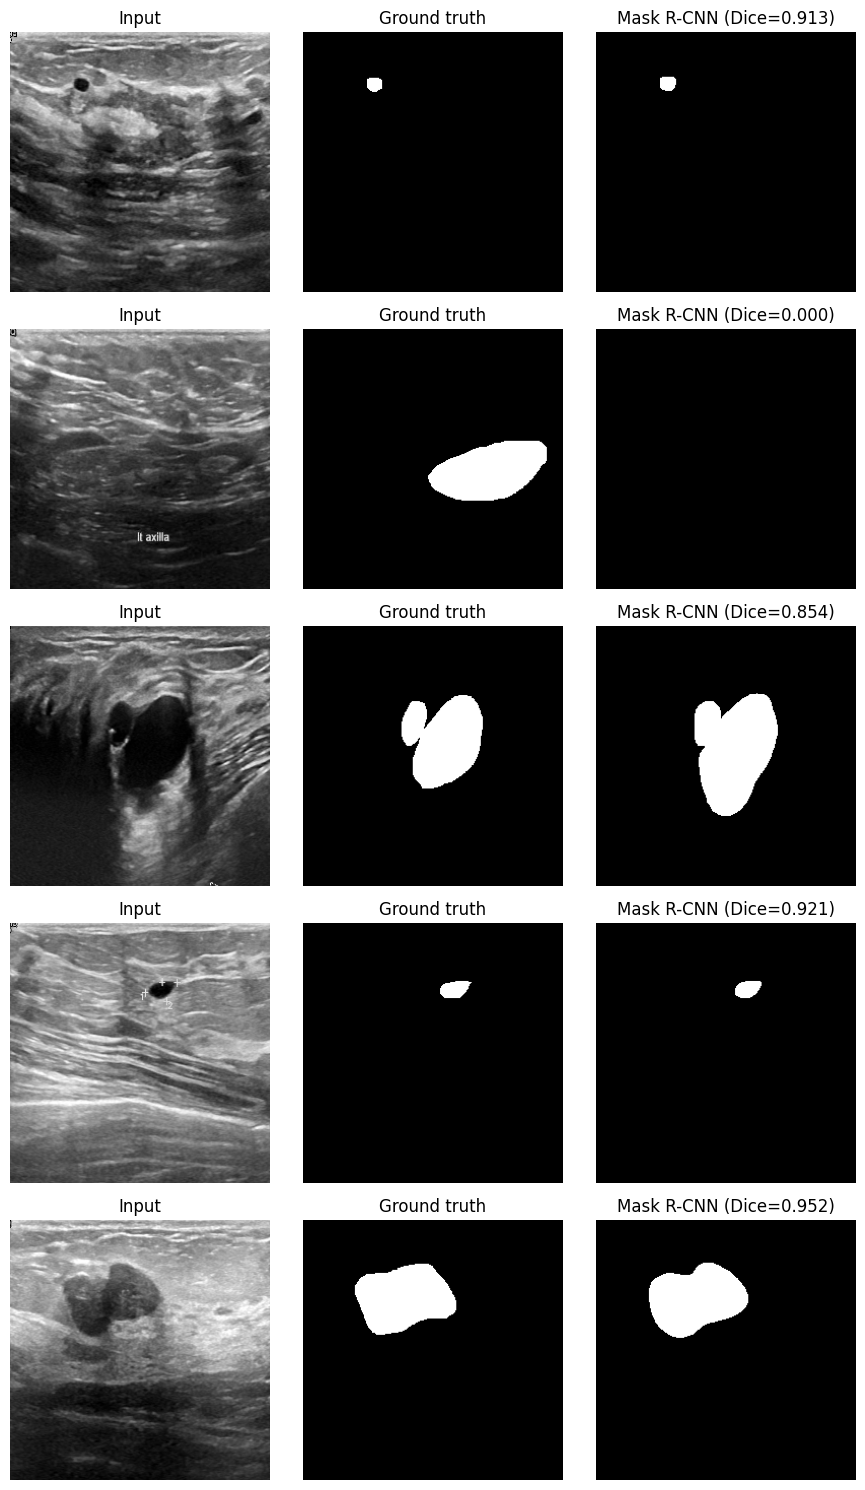

In [30]:
fig, axes = plt.subplots(5, 3, figsize=(9, 15))
for row, i in enumerate(idx_test[:5]):
    gt = masks[i, ..., 0]
    pred_mask = mrcnn_preds_store[i]
    d = dice_score(gt, pred_mask)

    axes[row, 0].imshow(imgs_raw[i], cmap='gray'); axes[row, 0].set_title('Input'); axes[row, 0].axis('off')
    axes[row, 1].imshow(gt, cmap='gray'); axes[row, 1].set_title('Ground truth'); axes[row, 1].axis('off')
    axes[row, 2].imshow(pred_mask, cmap='gray'); axes[row, 2].set_title(f'Mask R-CNN (Dice={d:.3f})'); axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

In [31]:
print(f"{'Metric':<15}{'U-Net':>13}{'Grad-CAM':>13}{'Mask R-CNN':>13}{'MedSAM':>13}")
print('-' * 65)
for m in metric_names:
    print(f"{m.capitalize():<15}"
          f"{np.mean(unet_results[m]):>13.4f}"
          f"{np.mean(gradcam_results[m]):>13.4f}"
          f"{np.mean(mrcnn_results[m]):>13.4f}"
          f"{np.mean(medsam_results[m]):>13.4f}")

Metric                 U-Net     Grad-CAM   Mask R-CNN       MedSAM
-----------------------------------------------------------------
Dice                  0.6019       0.1265       0.7478       0.9361
Iou                   0.5295       0.0735       0.6804       0.8820
Accuracy              0.9315       0.3585       0.9515       0.9852
Precision             0.7290       0.1973       0.8418       0.9256
Sensitivity           0.5806       0.6742       0.7851       0.9495
Specificity           0.9899       0.3424       0.9747       0.9888


In [32]:
print('unet' in dir())  # check the trained model is still there

True


In [33]:
X_test, y_test = imgs_norm[idx_test], masks[idx_test]

unet_preds = unet.predict(X_test)
print("Prediction stats — min:", unet_preds.min(), "max:", unet_preds.max(), "mean:", unet_preds.mean())

unet_results = {m: [] for m in metric_names}
for k in range(len(X_test)):
    scores = evaluate_all(y_test[k, ..., 0], unet_preds[k, ..., 0])
    for m in metric_names:
        unet_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(unet_results[m]):>15.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step
Prediction stats — min: 3.7276418e-06 max: 1.0 mean: 0.06634568
Metric              Mean Score
------------------------------
Dice                    0.6019
Iou                     0.5295
Accuracy                0.9315
Precision               0.7290
Sensitivity             0.5806
Specificity             0.9899


In [34]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', mode='max', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6),
]

history = unet.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=16, callbacks=callbacks)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 333ms/step - dice_coef: 0.8835 - loss: 0.1461 - val_dice_coef: 0.6464 - val_loss: 0.6478 - learning_rate: 6.2500e-06
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 326ms/step - dice_coef: 0.8861 - loss: 0.1534 - val_dice_coef: 0.6406 - val_loss: 0.6434 - learning_rate: 6.2500e-06
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 327ms/step - dice_coef: 0.8930 - loss: 0.1427 - val_dice_coef: 0.6399 - val_loss: 0.6386 - learning_rate: 6.2500e-06
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 328ms/step - dice_coef: 0.8947 - loss: 0.1412 - val_dice_coef: 0.6421 - val_loss: 0.6311 - learning_rate: 6.2500e-06
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 328ms/step - dice_coef: 0.8901 - loss: 0.1435 - val_dice_coef: 0.6414 - val_loss: 0.6337 - learning_rate: 6.2500e-06
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 327ms/step - dice_coef: 0.8891 - loss: 0.1465 - val_dice_coef: 0.6408 - val_loss: 0.6303 - learning_rate: 6.2500e-06
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 3

In [35]:
print('X_train' in dir(), 'y_train' in dir())

True True


In [36]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', mode='max', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6),
]

history = unet.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=16, callbacks=callbacks)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 334ms/step - dice_coef: 0.8922 - loss: 0.1459 - val_dice_coef: 0.6414 - val_loss: 0.6439 - learning_rate: 6.2500e-06
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 327ms/step - dice_coef: 0.9004 - loss: 0.1270 - val_dice_coef: 0.6384 - val_loss: 0.6419 - learning_rate: 6.2500e-06
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 327ms/step - dice_coef: 0.8944 - loss: 0.1393 - val_dice_coef: 0.6372 - val_loss: 0.6381 - learning_rate: 6.2500e-06
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 327ms/step - dice_coef: 0.8765 - loss: 0.1640 - val_dice_coef: 0.6340 - val_loss: 0.6436 - learning_rate: 6.2500e-06
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 329ms/step - dice_coef: 0.8906 - loss: 0.1469 - val_dice_coef: 0.6340 - val_loss: 0.6388 - learning_rate: 6.2500e-06
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 327ms/step - dice_coef: 0.9014 - loss: 0.1289 - val_dice_coef: 0.6363 - val_loss: 0.6365 - learning_rate: 6.2500e-06
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 

In [37]:
unet_preds = unet.predict(X_test)
print("Prediction stats — min:", unet_preds.min(), "max:", unet_preds.max(), "mean:", unet_preds.mean())

unet_results = {m: [] for m in metric_names}
for k in range(len(X_test)):
    scores = evaluate_all(y_test[k, ..., 0], unet_preds[k, ..., 0])
    for m in metric_names:
        unet_results[m].append(scores[m])

print(f"{'Metric':<15}{'Mean Score':>15}")
print('-' * 30)
for m in metric_names:
    print(f"{m.capitalize():<15}{np.mean(unet_results[m]):>15.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step
Prediction stats — min: 4.338537e-06 max: 1.0 mean: 0.06974248
Metric              Mean Score
------------------------------
Dice                    0.6216
Iou                     0.5488
Accuracy                0.9338
Precision               0.7324
Sensitivity             0.6013
Specificity             0.9898


In [38]:
print(f"{'Metric':<15}{'U-Net':>13}{'Grad-CAM':>13}{'Mask R-CNN':>13}{'MedSAM':>13}")
print('-' * 65)
for m in metric_names:
    print(f"{m.capitalize():<15}"
          f"{np.mean(unet_results[m]):>13.4f}"
          f"{np.mean(gradcam_results[m]):>13.4f}"
          f"{np.mean(mrcnn_results[m]):>13.4f}"
          f"{np.mean(medsam_results[m]):>13.4f}")

Metric                 U-Net     Grad-CAM   Mask R-CNN       MedSAM
-----------------------------------------------------------------
Dice                  0.6216       0.1265       0.7478       0.9361
Iou                   0.5488       0.0735       0.6804       0.8820
Accuracy              0.9338       0.3585       0.9515       0.9852
Precision             0.7324       0.1973       0.8418       0.9256
Sensitivity           0.6013       0.6742       0.7851       0.9495
Specificity           0.9898       0.3424       0.9747       0.9888


In [39]:
import matplotlib.pyplot as plt
import numpy as np

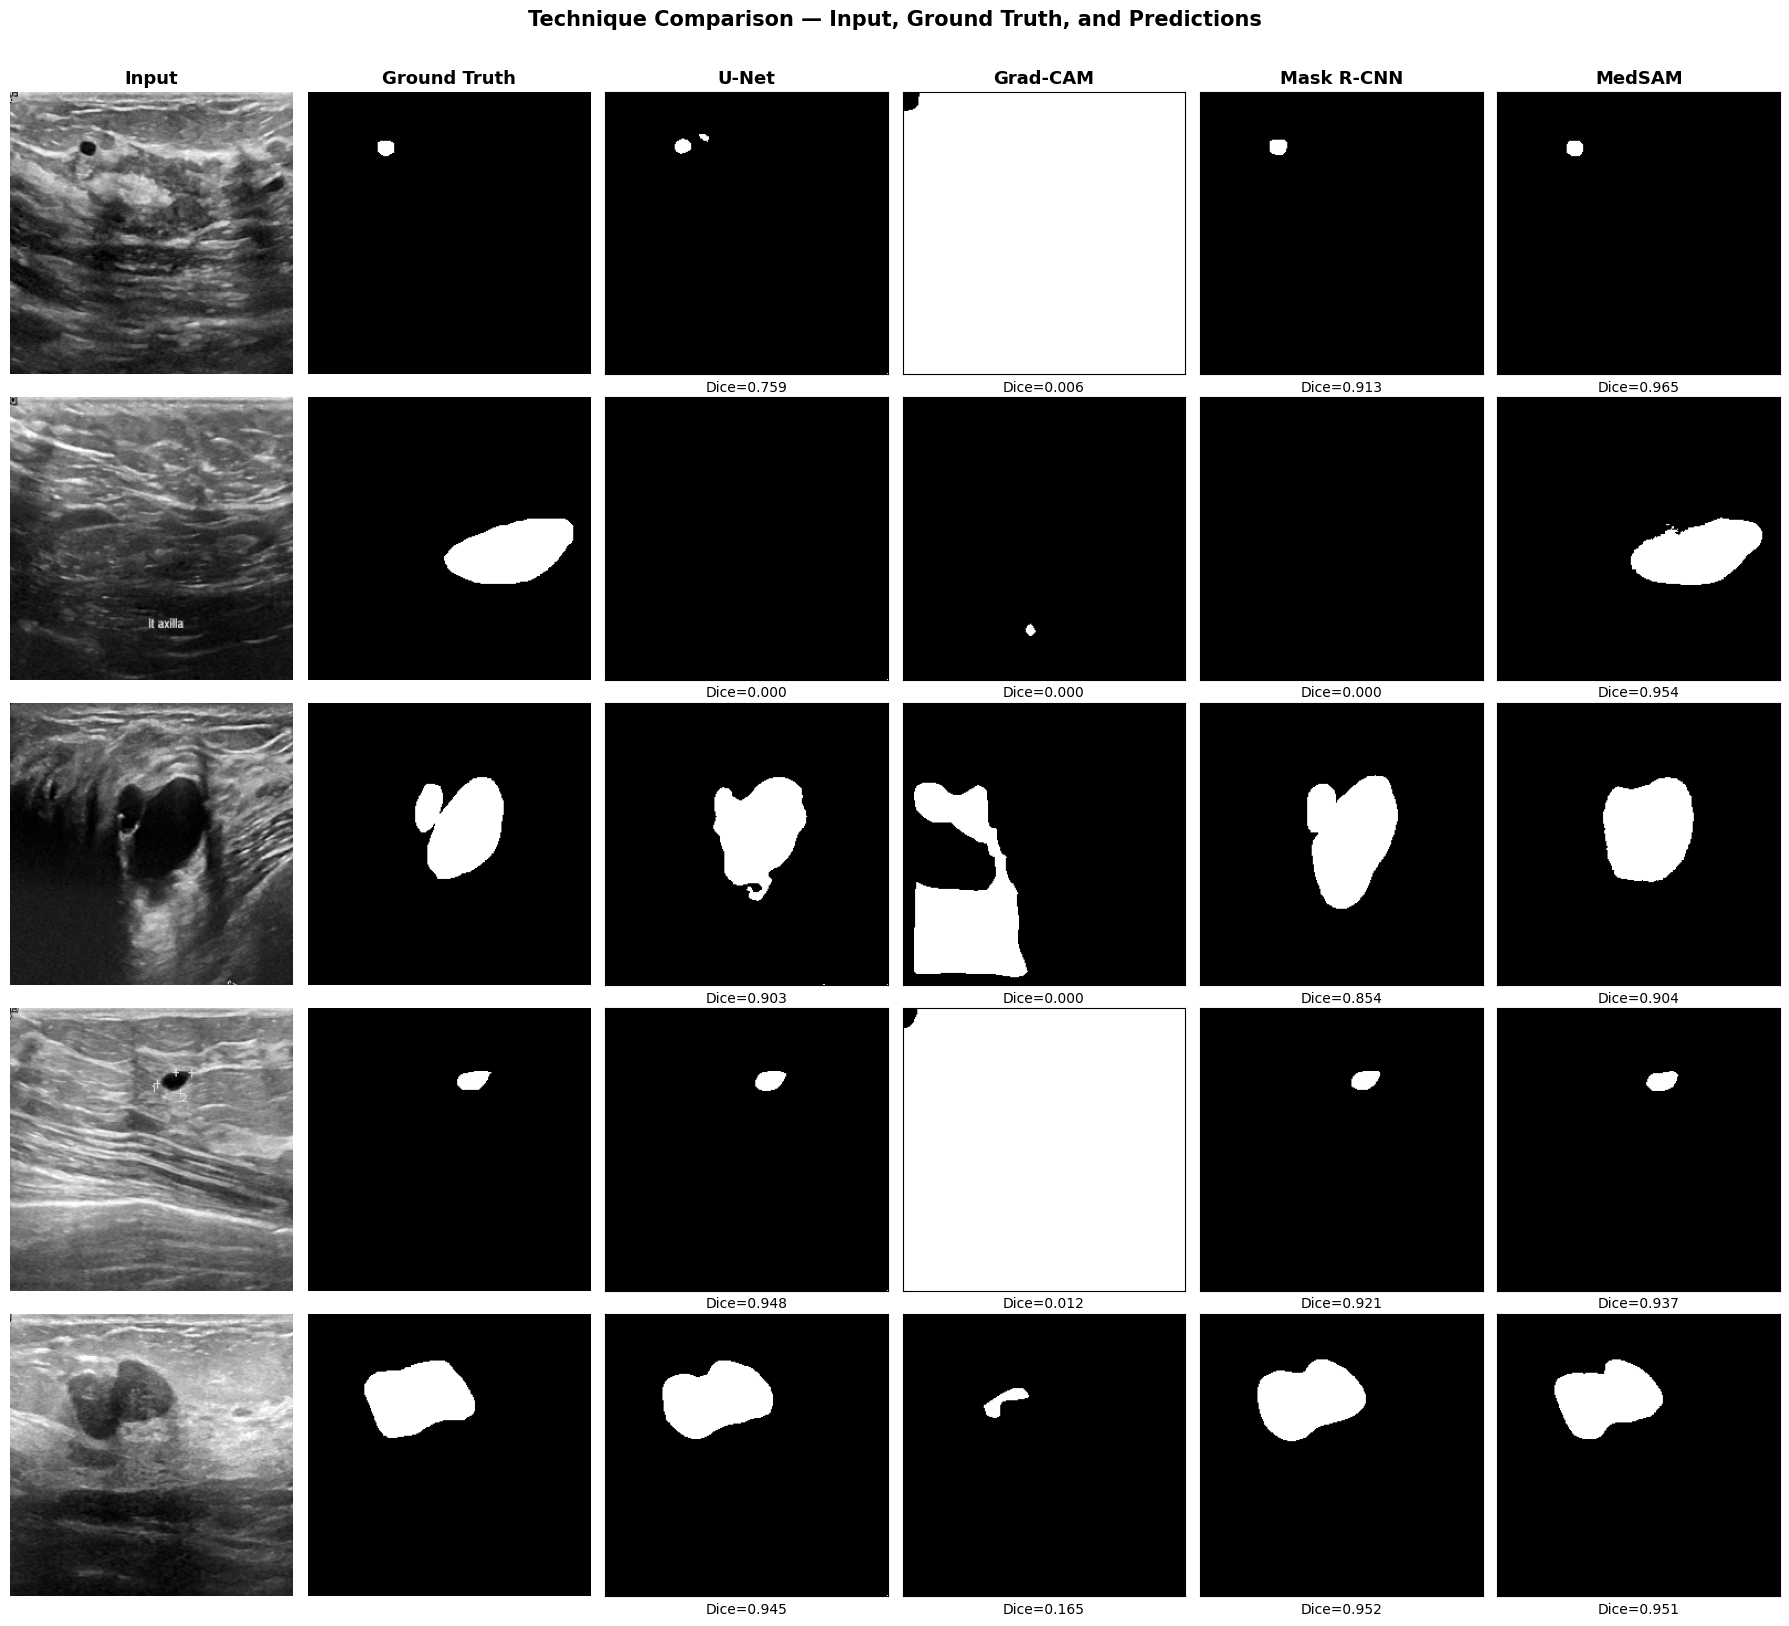

In [40]:
n_samples = 5
fig, axes = plt.subplots(n_samples, 6, figsize=(18, 3.2 * n_samples))

col_titles = ['Input', 'Ground Truth', 'U-Net', 'Grad-CAM', 'Mask R-CNN', 'MedSAM']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight='bold')

for row, i in enumerate(idx_test[:n_samples]):
    img_u8 = imgs_raw[i]
    gt = masks[i, ..., 0]

    # Input
    axes[row, 0].imshow(img_u8, cmap='gray')
    axes[row, 0].axis('off')

    # Ground truth
    axes[row, 1].imshow(gt, cmap='gray')
    axes[row, 1].axis('off')

    # U-Net
    unet_pred = unet.predict(imgs_norm[i][np.newaxis, ...], verbose=0)[0, ..., 0] > 0.5
    d_unet = dice_score(gt, unet_pred)
    axes[row, 2].imshow(unet_pred, cmap='gray')
    axes[row, 2].set_xlabel(f'Dice={d_unet:.3f}', fontsize=10)
    axes[row, 2].set_xticks([]); axes[row, 2].set_yticks([])

    # Grad-CAM
    heatmap = grad_cam(clf, imgs_norm[i])
    gradcam_pred = clean_mask(gradcam_to_mask(heatmap))
    d_gradcam = dice_score(gt, gradcam_pred)
    axes[row, 3].imshow(gradcam_pred, cmap='gray')
    axes[row, 3].set_xlabel(f'Dice={d_gradcam:.3f}', fontsize=10)
    axes[row, 3].set_xticks([]); axes[row, 3].set_yticks([])

    # Mask R-CNN
    mrcnn_pred = mrcnn_preds_store[i]
    d_mrcnn = dice_score(gt, mrcnn_pred)
    axes[row, 4].imshow(mrcnn_pred, cmap='gray')
    axes[row, 4].set_xlabel(f'Dice={d_mrcnn:.3f}', fontsize=10)
    axes[row, 4].set_xticks([]); axes[row, 4].set_yticks([])

    # MedSAM
    box = get_bbox_from_mask(gt)
    medsam_pred = medsam_inference(img_u8, box)
    d_medsam = dice_score(gt, medsam_pred)
    axes[row, 5].imshow(medsam_pred, cmap='gray')
    axes[row, 5].set_xlabel(f'Dice={d_medsam:.3f}', fontsize=10)
    axes[row, 5].set_xticks([]); axes[row, 5].set_yticks([])

plt.suptitle('Technique Comparison — Input, Ground Truth, and Predictions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('technique_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
for name in ['imgs_raw', 'masks', 'idx_test', 'dice_score', 'clean_mask',
             'unet', 'imgs_norm', 'clf', 'grad_cam', 'gradcam_to_mask',
             'mrcnn_preds_store', 'medsam_model', 'get_bbox_from_mask', 'medsam_inference']:
    print(f"{name}: {name in dir()}")

imgs_raw: True
masks: True
idx_test: True
dice_score: True
clean_mask: True
unet: True
imgs_norm: True
clf: True
grad_cam: True
gradcam_to_mask: True
mrcnn_preds_store: True
medsam_model: True
get_bbox_from_mask: True
medsam_inference: True


In [42]:
%whos

Variable                Type          Data/Info
-----------------------------------------------
BUSIInstanceDataset     type          <class '__main__.BUSIInstanceDataset'>
DATA_DIR                str           /kaggle/input/breast-ultrasound-images-dataset
DataLoader              type          <class 'torch.utils.data.dataloader.DataLoader'>
Dataset                 type          <class 'torch.utils.data.dataset.Dataset'>
F                       module        <module 'torch.nn.functio<...>/torch/nn/functional.py'>
FastRCNNPredictor       type          <class 'torchvision.model<...>_rcnn.FastRCNNPredictor'>
IMG_SIZE                int           256
K                       module        <module 'keras._tf_keras.<...>ras/backend/__init__.py'>
MaskRCNNPredictor       type          <class 'torchvision.model<...>_rcnn.MaskRCNNPredictor'>
X_test                  ndarray       98x256x256x1: 6422528 elems, type `float64`, 51380224 bytes (49.0 Mb)
X_train                 ndarray       452x256x25

In [43]:
print("imgs_raw" in globals())
print("masks" in globals())
print("imgs_norm" in globals())
print("idx_test" in globals())

True
True
True
True
